In [58]:
#Célula 1: Configuração Global e Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

#Configurações visuais:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("\nSetup concluído.")


Setup concluído.


In [65]:
#Célula 2: Lendo a base geral e filtrando o Rio Grande do Norte (CO_UF 24)
df_bruto = pd.read_csv('tbEstabelecimento202601.csv', sep=';', low_memory=False, encoding='latin1')
df_rn = df_bruto[df_bruto['CO_ESTADO_GESTOR'] == 24].copy()

#Seleção das 10 colunas:
colunas_selecionadas = [
    'TP_UNIDADE', 'CO_NATUREZA_JUR', 'TP_GESTAO', 'CO_TURNO_ATENDIMENTO',
    'TP_ESTAB_SEMPRE_ABERTO', 'CO_ATIVIDADE_PRINCIPAL', 'CO_CLIENTELA',
    'ST_CONEXAO_INTERNET', 'NU_LATITUDE', 'NU_LONGITUDE'
]
df_analise = df_rn[colunas_selecionadas].copy()

print(f"\nBase do RN pronta com {df_analise.shape[0]} registros.")


Base do RN pronta com 7448 registros.


--- PREPARANDO DADOS PARA DIAGNÓSTICO ---


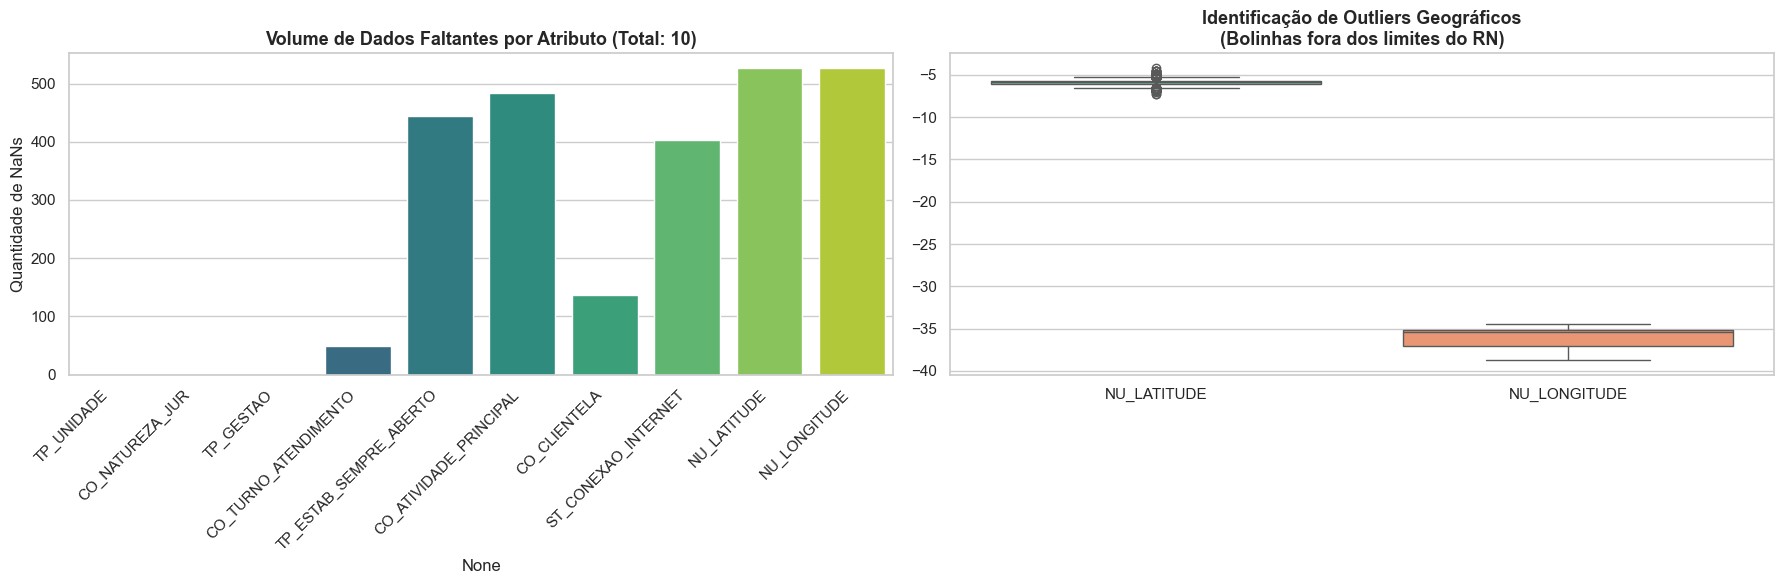


--- TABELA RESUMO ---


,Atributo,Total NaNs,% Faltante
0,TP_UNIDADE,0,0.00
1,CO_NATUREZA_JUR,0,0.00
2,TP_GESTAO,0,0.00
3,CO_TURNO_ATENDIMENTO,49,0.66
4,TP_ESTAB_SEMPRE_ABERTO,445,5.97
5,CO_ATIVIDADE_PRINCIPAL,484,6.50
6,CO_CLIENTELA,137,1.84
7,ST_CONEXAO_INTERNET,403,5.41
8,NU_LATITUDE,526,7.06
9,NU_LONGITUDE,526,7.06



FATO IMPORTANTE:
Serão removidas as 526 linhas sem coordenadas.


In [72]:
#Célula 3: Análise da Qualidade de Dados:
print("--- PREPARANDO DADOS PARA DIAGNÓSTICO ---")

#Tratando as coordenadas ANTES do diagnóstico:
for col in ['NU_LATITUDE', 'NU_LONGITUDE']:
    df_analise[col] = pd.to_numeric(df_analise[col].astype(str).str.replace(',', '.'), errors='coerce')

#Separando todas as colunas selecionadas:
colunas_10 = [
    'TP_UNIDADE', 'CO_NATUREZA_JUR', 'TP_GESTAO', 'CO_TURNO_ATENDIMENTO',
    'TP_ESTAB_SEMPRE_ABERTO', 'CO_ATIVIDADE_PRINCIPAL', 'CO_CLIENTELA',
    'ST_CONEXAO_INTERNET', 'NU_LATITUDE', 'NU_LONGITUDE'
]

plt.figure(figsize=(18, 6))


# Subplot 1: Gráfico de Barras (Obrigando a mostrar as 10 colunas)
plt.subplot(1, 2, 1)
nulos_10 = df_analise[colunas_10].isnull().sum()
# Usamos barplot do seaborn para um visual mais profissional
sns.barplot(x=nulos_10.index, y=nulos_10.values, hue=nulos_10.index, palette="viridis", legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Volume de Dados Faltantes por Atributo (Total: 10)', fontsize=13, fontweight='bold')
plt.ylabel('Quantidade de NaNs')

# Subplot 2: Boxplot de Outliers (Para identificar as bolinhas do mapa)
plt.subplot(1, 2, 2)
sns.boxplot(data=df_analise[['NU_LATITUDE', 'NU_LONGITUDE']], palette="Set2")
plt.title('Identificação de Outliers Geográficos\n(Bolinhas fora dos limites do RN)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('diagnostico_qualidade_dados.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- TABELA RESUMO ---")
resumo_nulos = pd.DataFrame({
    'Atributo': colunas_10,
    'Total NaNs': nulos_10.values,
    '% Faltante': (nulos_10.values / len(df_analise) * 100).round(2)
})
display(resumo_nulos)

nulos_gps = nulos_10['NU_LATITUDE']

print(f"\nFATO IMPORTANTE:")
print(f"Serão removidas as {nulos_gps} linhas sem coordenadas.")

--- CONSOLIDANDO A BASE FINAL ---


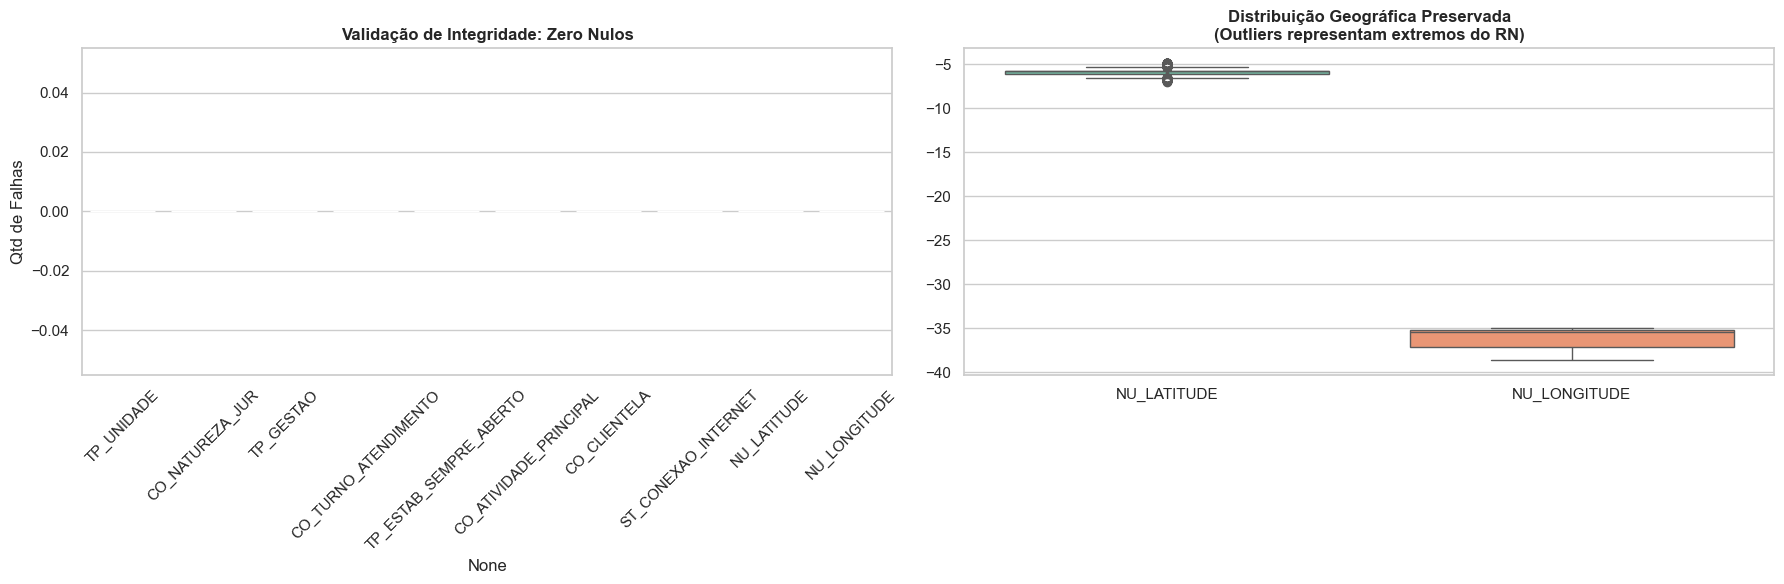

Base pronta: 6910 registros sem nulos.


In [88]:
#Célula 4: Consolidação da Base e Justificativa Técnica
print("--- CONSOLIDANDO A BASE FINAL ---")

#Limpeza de nulos nas coordenadas (Removendo apenas o que é nulo ou fora do quadrado do RN):
df_limpo = df_analise.dropna(subset=['NU_LATITUDE', 'NU_LONGITUDE']).copy()

#Limites amplos que garantem o RN todo mas tiram o 'lixo' de fora
df_limpo = df_limpo[
    (df_limpo['NU_LATITUDE'] <= -4.8) & (df_limpo['NU_LATITUDE'] >= -7.1) &
    (df_limpo['NU_LONGITUDE'] <= -34.7) & (df_limpo['NU_LONGITUDE'] >= -38.6)
]

#Tratando nulos restantes com a moda:
for col in df_limpo.columns:
    if df_limpo[col].isnull().sum() > 0:
        df_limpo[col] = df_limpo[col].fillna(df_limpo[col].mode()[0])

# --- VISUALIZAÇÃO PARA O ARTIGO ---
plt.figure(figsize=(18, 6))

#Subplot 1: Prova de que não há mais NULOS
plt.subplot(1, 2, 1)
nulos_finais = df_limpo[colunas_10].isnull().sum()
sns.barplot(x=nulos_finais.index, y=nulos_finais.values, color='seagreen')
plt.title('Validação de Integridade: Zero Nulos', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Qtd de Falhas')

#Subplot 2: O Boxplot que prova a preservação do interior
plt.subplot(1, 2, 2)
sns.boxplot(data=df_limpo[['NU_LATITUDE', 'NU_LONGITUDE']], palette="Set2")
plt.title('Distribuição Geográfica Preservada\n(Outliers representam extremos do RN)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('tratamento_qualidade_dados_final.png', dpi=300)
plt.show()

# Tabela Final para o "Check"
print(f"Base pronta: {len(df_limpo)} registros sem nulos.")

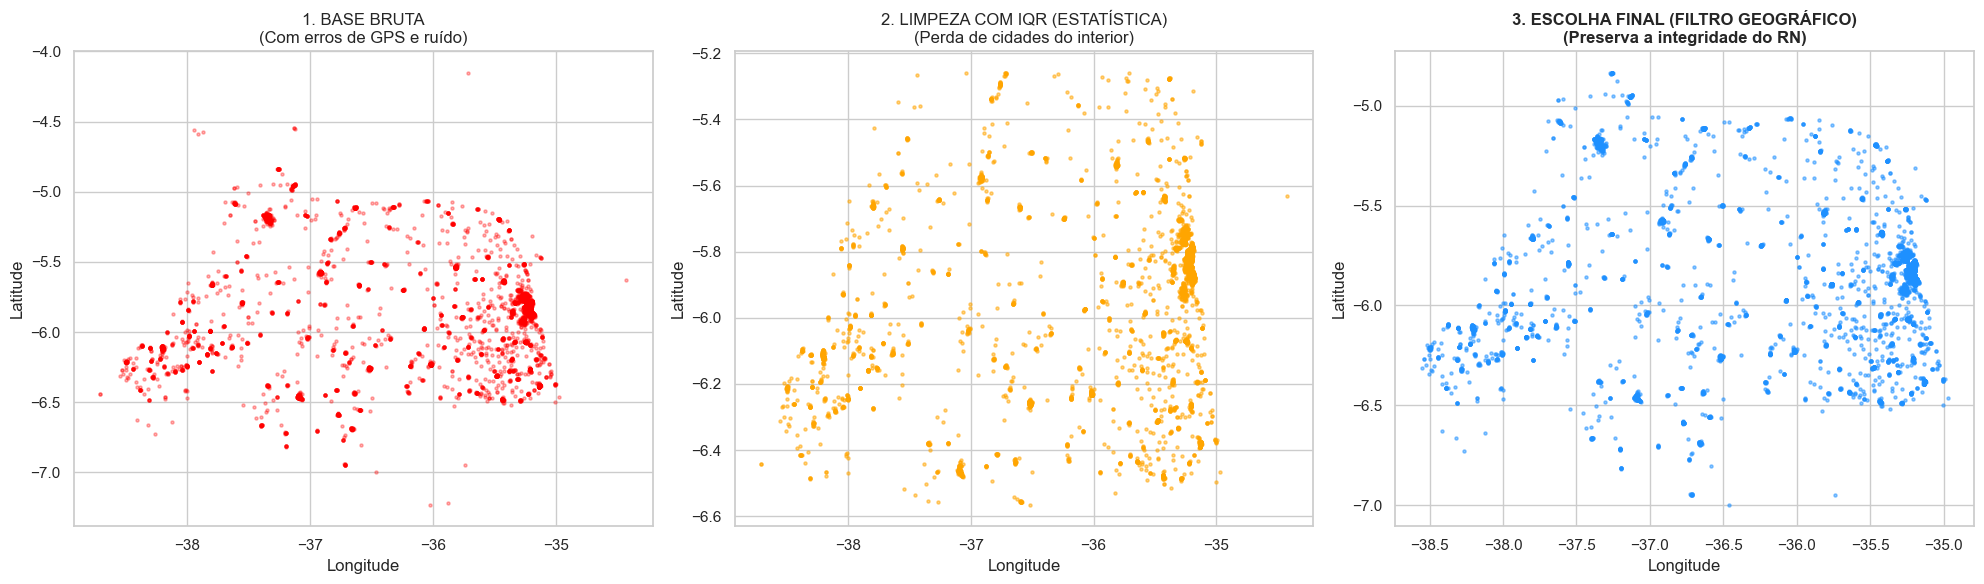

📊 Análise de Amostra:
- Base Bruta: 6922 postos
- Após IQR: 5841 postos (Perda excessiva!)
- Nossa Escolha: 6910 postos (Equilíbrio ideal)


In [90]:
#Célula 4.2: Comparativo de uso de IRQ para limpeza de outliers
df_original_geo = df_analise.dropna(subset=['NU_LATITUDE', 'NU_LONGITUDE']).copy()

#Cenário A: Limpeza com IQR (A que "corta" o estado)
Q1 = df_original_geo[['NU_LATITUDE', 'NU_LONGITUDE']].quantile(0.25)
Q3 = df_original_geo[['NU_LATITUDE', 'NU_LONGITUDE']].quantile(0.75)
IQR = Q3 - Q1
df_iqr = df_original_geo[~((df_original_geo[['NU_LATITUDE', 'NU_LONGITUDE']] < (Q1 - 1.5 * IQR)) |
                           (df_original_geo[['NU_LATITUDE', 'NU_LONGITUDE']] > (Q3 + 1.5 * IQR))).any(axis=1)]

#Cenário B: Escolha Final (Filtro Geográfico Real - df_limpo que já temos)

#Plotagem Tripla para o Artigo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#Mapa 1: Base Bruta sem tratamento
axes[0].scatter(df_original_geo['NU_LONGITUDE'], df_original_geo['NU_LATITUDE'], s=5, color='red', alpha=0.3)
axes[0].set_title('1. BASE BRUTA\n(Com erros de GPS e ruído)', fontsize=12)

#Mapa 2: Limpeza com IQR
axes[1].scatter(df_iqr['NU_LONGITUDE'], df_iqr['NU_LATITUDE'], s=5, color='orange', alpha=0.5)
axes[1].set_title('2. LIMPEZA COM IQR (ESTATÍSTICA)\n(Perda de cidades do interior)', fontsize=12)

#Mapa 3: Escolha Final com limpeza suave
axes[2].scatter(df_limpo['NU_LONGITUDE'], df_limpo['NU_LATITUDE'], s=5, color='dodgerblue', alpha=0.5)
axes[2].set_title('3. ESCOLHA FINAL (FILTRO GEOGRÁFICO)\n(Preserva a integridade do RN)', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('justificativa_metodologica_mapas.png', dpi=300)
plt.show()

print(f"📊 Análise de Amostra:")
print(f"- Base Bruta: {len(df_original_geo)} postos")
print(f"- Após IQR: {len(df_iqr)} postos (Perda excessiva!)")
print(f"- Nossa Escolha: {len(df_limpo)} postos (Equilíbrio ideal)")

In [92]:
#Célula 5: Transformação de Dados (One-Hot vs Frequency)
print("--- INICIANDO ENCODINGS ---")

#Definindo as colunas categóricas (texto) e as numéricas (coordenadas)
cols_cat = [c for c in df_limpo.columns if c not in ['NU_LATITUDE', 'NU_LONGITUDE']]

#Aplicando a lógica de "Top 5 + Outros" para One Hot Encoding:
df_top5 = df_limpo.copy()
for col in cols_cat:
    top_5 = df_top5[col].value_counts().nlargest(5).index
    df_top5[col] = df_top5[col].where(df_top5[col].isin(top_5), 'Outros')

df_onehot = pd.get_dummies(df_top5, columns=cols_cat, dtype=int)

#Aplicando Normalização no One Hot:
scaler_oh = StandardScaler()
df_final_onehot = pd.DataFrame(scaler_oh.fit_transform(df_onehot), columns=df_onehot.columns)


#FREQUENCY ENCODING (Baseado nos dados originais) ---
df_freq = df_limpo.copy()
for col in cols_cat:
    freq_map = df_freq[col].value_counts(normalize=True)
    df_freq[col] = df_freq[col].map(freq_map)

#Aplicando Normalização no Freq:
scaler_fr = StandardScaler()
df_final_freq = pd.DataFrame(scaler_fr.fit_transform(df_freq), columns=df_freq.columns)


#Exportação dos Arquivos para a Fase de Clusterização:
df_final_onehot.to_csv('base_sus_rn_onehot.csv', index=False)
df_final_freq.to_csv('base_sus_rn_frequencia.csv', index=False)

print(f"Base One-Hot: {df_final_onehot.shape[1]} colunas | Salva como 'base_sus_rn_onehot.csv'")
print(f"Base Frequência: {df_final_freq.shape[1]} colunas | Salva como 'base_sus_rn_frequencia.csv'")

#Visualização das tabelas:
display(df_final_onehot.head())
display(df_final_freq.head())

--- INICIANDO ENCODINGS ---
-> Base One-Hot: 36 colunas | Salva como 'base_sus_rn_onehot.csv'
-> Base Frequência: 10 colunas | Salva como 'base_sus_rn_frequencia.csv'


,NU_LATITUDE,NU_LONGITUDE,TP_UNIDADE_2,TP_UNIDADE_22,TP_UNIDADE_36,TP_UNIDADE_39,TP_UNIDADE_43,TP_UNIDADE_Outros,CO_NATUREZA_JUR_1031.0,CO_NATUREZA_JUR_1244.0,...,CO_ATIVIDADE_PRINCIPAL_2.0,CO_ATIVIDADE_PRINCIPAL_8.0,CO_ATIVIDADE_PRINCIPAL_12.0,CO_ATIVIDADE_PRINCIPAL_22.0,CO_ATIVIDADE_PRINCIPAL_Outros,CO_CLIENTELA_1.0,CO_CLIENTELA_2.0,CO_CLIENTELA_3.0,ST_CONEXAO_INTERNET_N,ST_CONEXAO_INTERNET_S
0,0.133843,0.831550,-0.432057,-0.605105,-0.539543,3.668251,-0.271996,-0.517356,-0.160721,-0.710717,...,3.341481,-0.238872,-0.476130,-0.199307,-0.428751,-1.022244,-0.212668,1.115126,-0.324417,0.324417
1,2.347688,-1.049414,-0.432057,-0.605105,-0.539543,-0.272609,-0.271996,1.932905,-0.160721,1.407030,...,-0.299269,-0.238872,2.100267,-0.199307,-0.428751,0.978240,-0.212668,-0.896759,3.082454,-3.082454
2,2.360506,-1.043737,2.314508,-0.605105,-0.539543,-0.272609,-0.271996,-0.517356,-0.160721,1.407030,...,-0.299269,-0.238872,2.100267,-0.199307,-0.428751,-1.022244,-0.212668,1.115126,3.082454,-3.082454
3,-0.887255,0.788855,2.314508,-0.605105,-0.539543,-0.272609,-0.271996,-0.517356,-0.160721,1.407030,...,-0.299269,-0.238872,2.100267,-0.199307,-0.428751,-1.022244,-0.212668,1.115126,-0.324417,0.324417
4,-0.951216,0.885763,2.314508,-0.605105,-0.539543,-0.272609,-0.271996,-0.517356,-0.160721,1.407030,...,-0.299269,-0.238872,2.100267,-0.199307,-0.428751,-1.022244,-0.212668,1.115126,-0.324417,0.324417


,TP_UNIDADE,CO_NATUREZA_JUR,TP_GESTAO,CO_TURNO_ATENDIMENTO,TP_ESTAB_SEMPRE_ABERTO,CO_ATIVIDADE_PRINCIPAL,CO_CLIENTELA,ST_CONEXAO_INTERNET,NU_LATITUDE,NU_LONGITUDE
0,-0.947915,0.645234,0.147942,0.493477,0.271382,-0.989971,-0.168634,0.324417,0.133843,0.831550
1,-1.190955,0.657617,0.147942,0.493477,0.271382,-0.485018,0.521981,-3.082454,2.347688,-1.049414
2,-0.039870,0.657617,0.147942,0.493477,0.271382,-0.485018,-0.168634,-3.082454,2.360506,-1.043737
3,-0.039870,0.657617,0.147942,0.493477,0.271382,-0.485018,-0.168634,0.324417,-0.887255,0.788855
4,-0.039870,0.657617,0.147942,0.493477,0.271382,-0.485018,-0.168634,0.324417,-0.951216,0.885763


In [29]:
print("\n--- FASE 2: Iniciando tratamento com K-Means (Iniciando processamento em lote) ---")

#Carregando a base com One Hot Encoding:
df = pd.read_csv('base_sus_rn_tratada.csv')

#Dicionário para guardar as notas de cada teste:
resultados_kmeans = {
    'k': [],
    'silhouette_kpp': [], 'db_kpp': [],
    'silhouette_random': [], 'db_random': []
}

print("\nIniciando o loop do K-Means (k variando de 2 a 10)...")
inicio_tempo = time.time()

#O Loop entre 2 e 10 Ks.
for k in range(2, 11):
    print(f"Treinando para k={k}...")

    #Teste A: init = 'k-means++'
    kmeans_kpp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_kpp = kmeans_kpp.fit_predict(df)

    #Teste B: init = 'random'
    kmeans_random = KMeans(n_clusters=k, init='ran  dom', n_init=10, random_state=42)
    labels_random = kmeans_random.fit_predict(df)

    #Guardando o K atual
    resultados_kmeans['k'].append(k)

    #Calculando e guardando as notas do k-means++
    resultados_kmeans['silhouette_kpp'].append(silhouette_score(df, labels_kpp))
    resultados_kmeans['db_kpp'].append(davies_bouldin_score(df, labels_kpp))

    #Calculando e guardando as notas do random
    resultados_kmeans['silhouette_random'].append(silhouette_score(df, labels_random))
    resultados_kmeans['db_random'].append(davies_bouldin_score(df, labels_random))

#Desligando o cronômetro:
fim_tempo = time.time()
tempo_total = (fim_tempo - inicio_tempo) / 60

print(f"\nEtapa com K-Means finalizado com sucesso")
print(f"Tempo total de execução: {tempo_total:.2f} minutos.")

#Convertendo os resultados e salvando num CSV de segurança:
df_resultados_kmeans = pd.DataFrame(resultados_kmeans)
df_resultados_kmeans.to_csv('resultados_kmeans_sus.csv', index=False)
print("As notas foram salvas no arquivo 'resultados_kmeans_sus.csv'.")


--- FASE 2: Iniciando tratamento com K-Means (Iniciando processamento em lote) ---

Iniciando o loop do K-Means (k variando de 2 a 10)...
Treinando para k=2...
Treinando para k=3...
Treinando para k=4...
Treinando para k=5...
Treinando para k=6...
Treinando para k=7...
Treinando para k=8...
Treinando para k=9...
Treinando para k=10...

Etapa com K-Means finalizado com sucesso
Tempo total de execução: 0.27 minutos.
As notas foram salvas no arquivo 'resultados_kmeans_sus.csv'.


In [30]:
import pandas as pd
import time
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("\n--- FASE 2: Iniciado tratamento com Hierárquico Aglomerativo ---")

#Carregando a base com One Hot Encoding:
df = pd.read_csv('base_sus_rn_tratada.csv')

#Dicionário para guardar as notas
resultados_hc = {
    'k': [],
    'linkage': [],
    'silhouette': [],
    'db': []
}

linkages = ['ward', 'complete', 'average', 'single']

print("\nIniciando a construção das árvores de cluster:")
inicio_tempo = time.time()

#O Loop duplo: variando o k e o tipo de ligação:
for k in range(2, 11):
    for link in linkages:
        print(f"Construindo árvore para k={k} usando linkage='{link}'...")

        #Criando e treinando o modelo
        hc = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = hc.fit_predict(df)

        #Salvando os resultados da rodada
        resultados_hc['k'].append(k)
        resultados_hc['linkage'].append(link)
        resultados_hc['silhouette'].append(silhouette_score(df, labels))
        resultados_hc['db'].append(davies_bouldin_score(df, labels))

fim_tempo = time.time()
tempo_total = (fim_tempo - inicio_tempo) / 60

print(f"\nHierárquico Aglomerativo finalizado com sucesso!")
print(f"Tempo total de execução: {tempo_total:.2f} minutos.")

df_resultados_hc = pd.DataFrame(resultados_hc)
df_resultados_hc.to_csv('resultados_hierarquico_sus.csv', index=False)
print("As notas foram salvas no arquivo 'resultados_hierarquico_sus.csv'.")


--- FASE 2: Iniciado tratamento com Hierárquico Aglomerativo ---

Iniciando a construção das árvores de cluster:
Construindo árvore para k=2 usando linkage='ward'...
Construindo árvore para k=2 usando linkage='complete'...
Construindo árvore para k=2 usando linkage='average'...
Construindo árvore para k=2 usando linkage='single'...
Construindo árvore para k=3 usando linkage='ward'...
Construindo árvore para k=3 usando linkage='complete'...
Construindo árvore para k=3 usando linkage='average'...
Construindo árvore para k=3 usando linkage='single'...
Construindo árvore para k=4 usando linkage='ward'...
Construindo árvore para k=4 usando linkage='complete'...
Construindo árvore para k=4 usando linkage='average'...
Construindo árvore para k=4 usando linkage='single'...
Construindo árvore para k=5 usando linkage='ward'...
Construindo árvore para k=5 usando linkage='complete'...
Construindo árvore para k=5 usando linkage='average'...
Construindo árvore para k=5 usando linkage='single'...
Co

In [31]:
import pandas as pd
import time
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("\n--- FASE 2: Iniciando tratamento com Expectation Maximization (Gaussian Mixture) ---")

#Carregando a base com One Hot Encoding:
df = pd.read_csv('base_sus_rn_tratada.csv')

#Dicionário para guardar as notas:
resultados_em = {
    'k': [],
    'covariance_type': [],
    'silhouette': [],
    'db': []
}

covariances = ['full', 'tied', 'diag', 'spherical']

print("\nIniciando o treinamento dos modelos EM...")
inicio_tempo = time.time()

#Loop duplo: variando o k e o formato da covariância:
for k in range(2, 11):
    for cov in covariances:
        print(f"Ajustando modelo para k={k} com covariance_type='{cov}'...")

        #Criando e treinando o modelo
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)

        #O GMM usa o predict para gerar os rótulos de qual grupo cada posto pertence
        labels = gmm.fit_predict(df)

        #Salvando os resultados da rodada
        resultados_em['k'].append(k)
        resultados_em['covariance_type'].append(cov)
        resultados_em['silhouette'].append(silhouette_score(df, labels))
        resultados_em['db'].append(davies_bouldin_score(df, labels))

fim_tempo = time.time()
tempo_total = (fim_tempo - inicio_tempo) / 60

print(f"\nExpectation Maximization (EM) finalizado com sucesso!")
print(f"Tempo total de execução: {tempo_total:.2f} minutos.")

#Exportando os resultados finais da Fase 2:
df_resultados_em = pd.DataFrame(resultados_em)
df_resultados_em.to_csv('resultados_em_sus.csv', index=False)
print("As notas foram salvas no arquivo 'resultados_em_sus.csv'.\nA Fase 2 está finalizada!")


--- FASE 2: Iniciando tratamento com Expectation Maximization (Gaussian Mixture) ---

Iniciando o treinamento dos modelos EM...
Ajustando modelo para k=2 com covariance_type='full'...
Ajustando modelo para k=2 com covariance_type='tied'...
Ajustando modelo para k=2 com covariance_type='diag'...
Ajustando modelo para k=2 com covariance_type='spherical'...
Ajustando modelo para k=3 com covariance_type='full'...
Ajustando modelo para k=3 com covariance_type='tied'...
Ajustando modelo para k=3 com covariance_type='diag'...
Ajustando modelo para k=3 com covariance_type='spherical'...
Ajustando modelo para k=4 com covariance_type='full'...
Ajustando modelo para k=4 com covariance_type='tied'...
Ajustando modelo para k=4 com covariance_type='diag'...
Ajustando modelo para k=4 com covariance_type='spherical'...
Ajustando modelo para k=5 com covariance_type='full'...
Ajustando modelo para k=5 com covariance_type='tied'...
Ajustando modelo para k=5 com covariance_type='diag'...
Ajustando modelo


--- FASE 3: Validação Visual (Resultados K-Means com One-Hot) ---



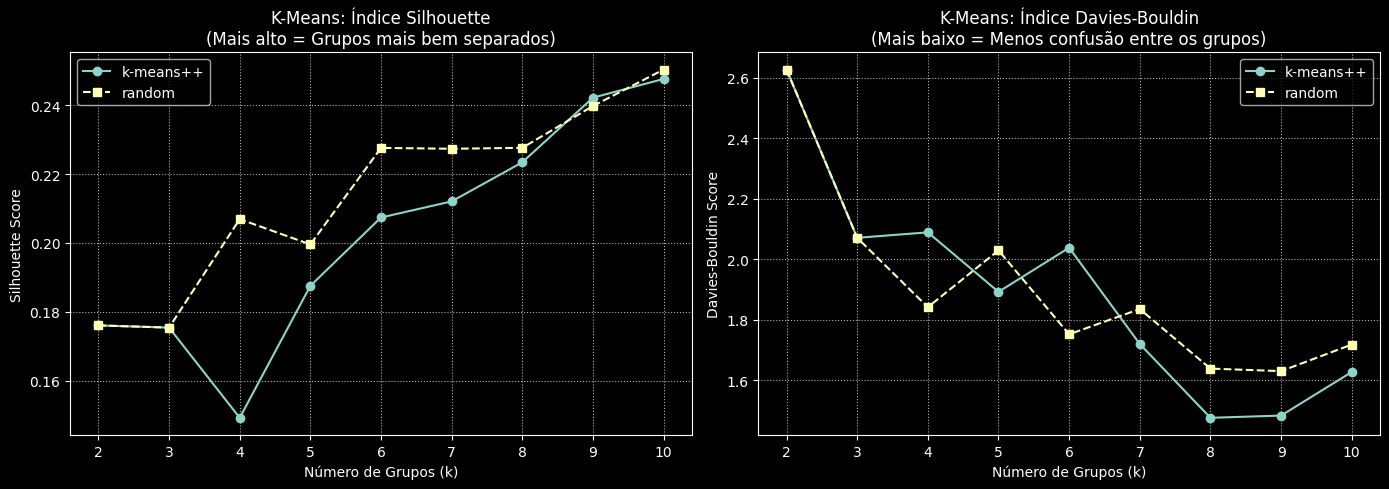

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

print("\n--- FASE 3: Validação Visual (Resultados K-Means com One-Hot) ---\n")

#Carregando os resultados gerados:
df_kmeans = pd.read_csv('resultados_kmeans_sus.csv')

#Configurando a tela de desenho:
plt.figure(figsize=(14, 5))


# Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1) # (1 linha, 2 colunas, 1º gráfico)
plt.plot(df_kmeans['k'], df_kmeans['silhouette_kpp'], marker='o', label='k-means++')
plt.plot(df_kmeans['k'], df_kmeans['silhouette_random'], marker='s', linestyle='--', label='random')
plt.title('K-Means: Índice Silhouette\n(Mais alto = Grupos mais bem separados)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Silhouette Score')
plt.xticks(df_kmeans['k']) # Garante que todos os números de k apareçam no eixo X
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()


# Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2) # (1 linha, 2 colunas, 2º gráfico)
plt.plot(df_kmeans['k'], df_kmeans['db_kpp'], marker='o', label='k-means++')
plt.plot(df_kmeans['k'], df_kmeans['db_random'], marker='s', linestyle='--', label='random')
plt.title('K-Means: Índice Davies-Bouldin\n(Mais baixo = Menos confusão entre os grupos)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(df_kmeans['k'])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

#Ajuste de espaços e exibição final:
plt.tight_layout()
plt.savefig('grafico_fase3_kmeans-onehot.png', dpi=300, bbox_inches='tight')
plt.show()


--- FASE 3: Validação Visual (Resultados Hierárquico com One-Hot) ---



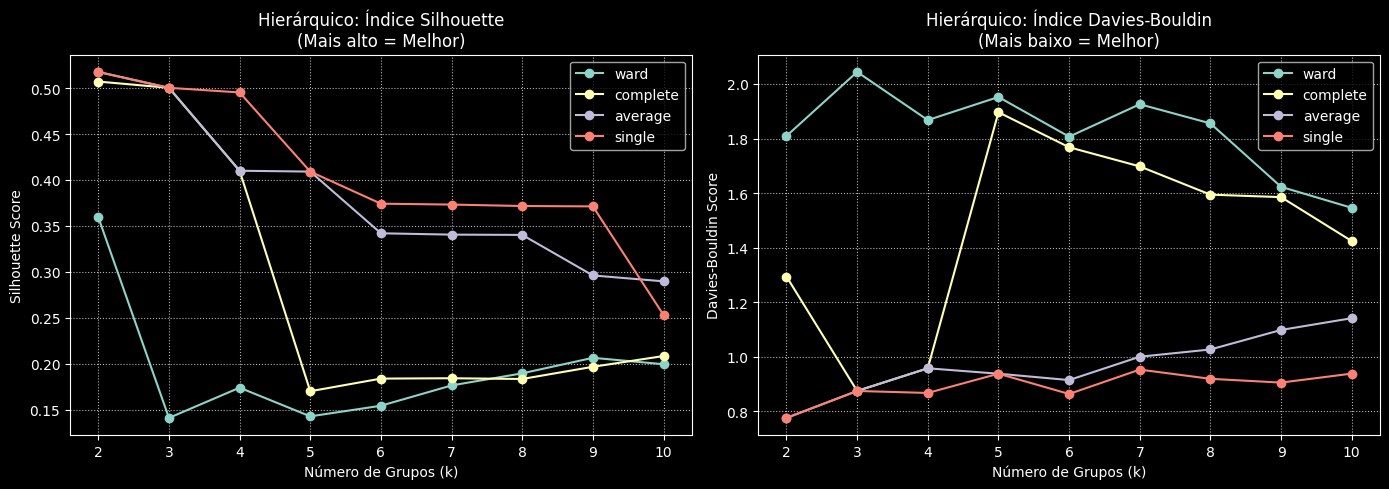

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

print("\n--- FASE 3: Validação Visual (Resultados Hierárquico com One-Hot) ---\n")

#Carregando os resultados do Hierárquico:
df_hc = pd.read_csv('resultados_hierarquico_sus.csv')
linkages = df_hc['linkage'].unique()

#Configurando a tela:
plt.figure(figsize=(14, 5))


#Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1)
for link in linkages:
    df_plot = df_hc[df_hc['linkage'] == link]
    plt.plot(df_plot['k'], df_plot['silhouette'], marker='o', label=link)

plt.title('Hierárquico: Índice Silhouette\n(Mais alto = Melhor)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()


#Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2)
for link in linkages:
    df_plot = df_hc[df_hc['linkage'] == link]
    plt.plot(df_plot['k'], df_plot['db'], marker='o', label=link)

plt.title('Hierárquico: Índice Davies-Bouldin\n(Mais baixo = Melhor)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()


plt.tight_layout()
plt.savefig('grafico_fase3_hierarquico-onehot.png', dpi=300, bbox_inches='tight')
plt.show()


--- FASE 3: Validação Visual (Resultados EM / Gaussian Mixture) ---



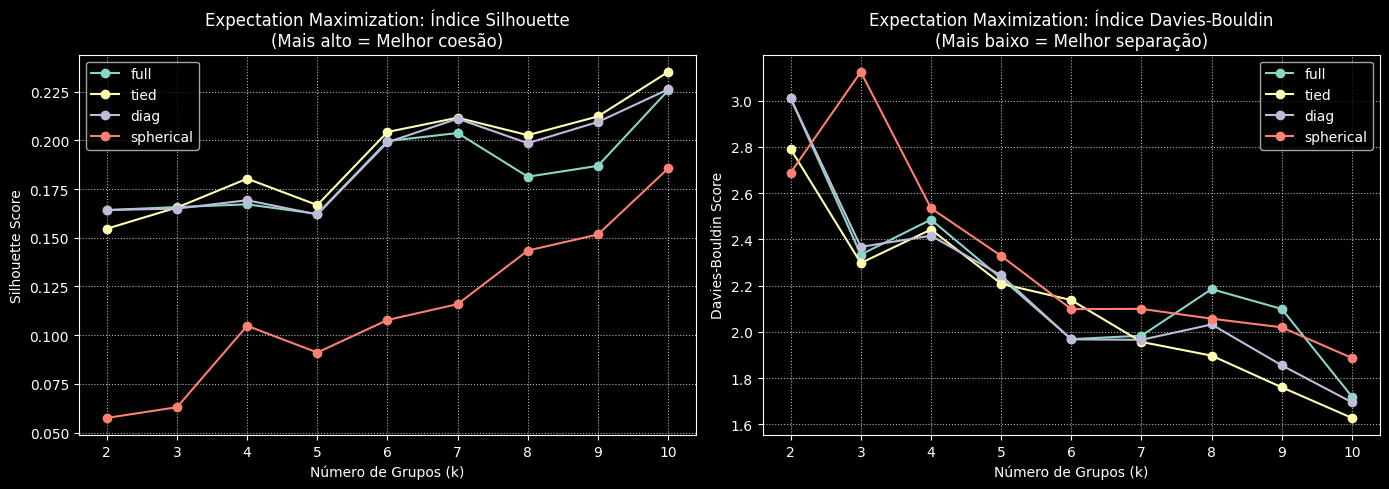

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

print("\n--- FASE 3: Validação Visual (Resultados EM / Gaussian Mixture) ---\n")

#Carregando os resultados do EM:
df_em = pd.read_csv('resultados_em_sus.csv')
covariances = df_em['covariance_type'].unique()

#Configurando a tela de desenho:
plt.figure(figsize=(14, 5))

#Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1)
for cov in covariances:
    df_plot = df_em[df_em['covariance_type'] == cov]
    plt.plot(df_plot['k'], df_plot['silhouette'], marker='o', label=cov)

plt.title('Expectation Maximization: Índice Silhouette\n(Mais alto = Melhor coesão)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

#Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2)
for cov in covariances:
    df_plot = df_em[df_em['covariance_type'] == cov]
    plt.plot(df_plot['k'], df_plot['db'], marker='o', label=cov)

plt.title('Expectation Maximization: Índice Davies-Bouldin\n(Mais baixo = Melhor separação)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig('grafico_fase3_em-onehot.png', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
import pandas as pd
import time
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("\n--- FASE 2 (RODADA FREQUÊNCIA): K-Means ---\n")

#Carregando a base tratada com Frequency Encoding:
df_freq = pd.read_csv('base_sus_rn_frequencia.csv')

#Guardando as notas do teste de Frequência:
resultados_kmeans_freq = {
    'k': [],
    'silhouette_kpp': [], 'db_kpp': [],
    'silhouette_random': [], 'db_random': []
}

print("\nIniciando o loop do K-Means na base de Frequência (k de 2 a 10)...")
inicio_tempo = time.time()

#O Loop de 2 a 10 Ks:
for k in range(2, 11):
    print(f"Treinando para k={k}...")

    #Teste A: init = 'k-means++'
    kmeans_kpp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_kpp = kmeans_kpp.fit_predict(df_freq)

    #Teste B: init = 'random'
    kmeans_random = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)
    labels_random = kmeans_random.fit_predict(df_freq)

    resultados_kmeans_freq['k'].append(k)

    resultados_kmeans_freq['silhouette_kpp'].append(silhouette_score(df_freq, labels_kpp))
    resultados_kmeans_freq['db_kpp'].append(davies_bouldin_score(df_freq, labels_kpp))

    resultados_kmeans_freq['silhouette_random'].append(silhouette_score(df_freq, labels_random))
    resultados_kmeans_freq['db_random'].append(davies_bouldin_score(df_freq, labels_random))

fim_tempo = time.time()
tempo_total = (fim_tempo - inicio_tempo) / 60

print(f"\nK-Means com a base em Frequência finalizado com sucesso!")
print(f"Tempo total de execução: {tempo_total:.2f} minutos.")

#Salvando arquivo:
df_resultados_kmeans_freq = pd.DataFrame(resultados_kmeans_freq)
df_resultados_kmeans_freq.to_csv('resultados_kmeans_sus_freq.csv', index=False)
print("Notas salvas no arquivo 'resultados_kmeans_sus_freq.csv'.")


--- FASE 2 (RODADA FREQUÊNCIA): K-Means ---


Iniciando o loop do K-Means na base de Frequência (k de 2 a 10)...
Treinando para k=2...
Treinando para k=3...
Treinando para k=4...
Treinando para k=5...
Treinando para k=6...
Treinando para k=7...
Treinando para k=8...
Treinando para k=9...
Treinando para k=10...

K-Means com a base em Frequência finalizado com sucesso!
Tempo total de execução: 0.23 minutos.
Notas salvas no arquivo 'resultados_kmeans_sus_freq.csv'.


In [51]:
import pandas as pd
import time
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("\n--- FASE 2 (RODADA FREQUÊNCIA): Hierárquico Aglomerativo ---\n")

#Carregando a base tratada com Frequency Encoding:
df_freq = pd.read_csv('base_sus_rn_frequencia.csv')

#Guardando as notas do teste de Frequência:
resultados_hc_freq = {
    'k': [],
    'linkage': [],
    'silhouette': [],
    'db': []
}

linkages = ['ward', 'complete', 'average', 'single']

print("Iniciando a construção das árvores na base de Frequência...\n")
inicio_tempo = time.time()

#O Loop duplo: variando o k e o tipo de ligação:
for k in range(2, 11):
    for link in linkages:
        print(f"Construindo árvore para k={k} usando linkage='{link}'...")

        #Criando e treinando o modelo
        hc = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = hc.fit_predict(df_freq)

        #Salvando os resultados da rodada
        resultados_hc_freq['k'].append(k)
        resultados_hc_freq['linkage'].append(link)
        resultados_hc_freq['silhouette'].append(silhouette_score(df_freq, labels))
        resultados_hc_freq['db'].append(davies_bouldin_score(df_freq, labels))

fim_tempo = time.time()
tempo_total = (fim_tempo - inicio_tempo) / 60

print(f"\nHierárquico Aglomerativo com base em Frequência finalizado com sucesso!")
print(f"Tempo total de execução: {tempo_total:.2f} minutos.")


df_resultados_hc_freq = pd.DataFrame(resultados_hc_freq)
df_resultados_hc_freq.to_csv('resultados_hierarquico_sus_freq.csv', index=False)
print("Notas salvas no arquivo 'resultados_hierarquico_sus_freq.csv'.")


--- FASE 2 (RODADA FREQUÊNCIA): Hierárquico Aglomerativo ---

Iniciando a construção das árvores na base de Frequência...

Construindo árvore para k=2 usando linkage='ward'...
Construindo árvore para k=2 usando linkage='complete'...
Construindo árvore para k=2 usando linkage='average'...
Construindo árvore para k=2 usando linkage='single'...
Construindo árvore para k=3 usando linkage='ward'...
Construindo árvore para k=3 usando linkage='complete'...
Construindo árvore para k=3 usando linkage='average'...
Construindo árvore para k=3 usando linkage='single'...
Construindo árvore para k=4 usando linkage='ward'...
Construindo árvore para k=4 usando linkage='complete'...
Construindo árvore para k=4 usando linkage='average'...
Construindo árvore para k=4 usando linkage='single'...
Construindo árvore para k=5 usando linkage='ward'...
Construindo árvore para k=5 usando linkage='complete'...
Construindo árvore para k=5 usando linkage='average'...
Construindo árvore para k=5 usando linkage='sin

In [52]:
import pandas as pd
import time
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("\n--- FASE 2 (RODADA FREQUÊNCIA): Expectation Maximization (EM) ---\n")

#Carregando a base tratada com Frequency Encoding:
df_freq = pd.read_csv('base_sus_rn_frequencia.csv')

#Guardando as notas do teste de EM:
resultados_em_freq = {
    'k': [],
    'covariance_type': [],
    'silhouette': [],
    'db': []
}

covariances = ['full', 'tied', 'diag', 'spherical']

print("Iniciando o loop do EM / Gaussian Mixture na base de Frequência...")
inicio_tempo = time.time()

#O Loop duplo: variando o k e a covariância:
for k in range(2, 11):
    for cov in covariances:
        print(f"Treinando modelo EM para k={k} com covariância='{cov}'...")

        #Criando e treinando o modelo
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        labels = gmm.fit_predict(df_freq)

        #Salvando os resultados da rodada
        resultados_em_freq['k'].append(k)
        resultados_em_freq['covariance_type'].append(cov)
        resultados_em_freq['silhouette'].append(silhouette_score(df_freq, labels))
        resultados_em_freq['db'].append(davies_bouldin_score(df_freq, labels))

fim_tempo = time.time()
tempo_total = (fim_tempo - inicio_tempo) / 60

print(f"\nExpectation Maximization (Frequência) finalizado com sucesso!")
print(f"Tempo total de execução: {tempo_total:.2f} minutos.")

df_resultados_em_freq = pd.DataFrame(resultados_em_freq)
df_resultados_em_freq.to_csv('resultados_em_sus_freq.csv', index=False)
print("Notas salvas no arquivo 'resultados_em_sus_freq.csv'.")


--- FASE 2 (RODADA FREQUÊNCIA): Expectation Maximization (EM) ---

Iniciando o loop do EM / Gaussian Mixture na base de Frequência...
Treinando modelo EM para k=2 com covariância='full'...
Treinando modelo EM para k=2 com covariância='tied'...
Treinando modelo EM para k=2 com covariância='diag'...
Treinando modelo EM para k=2 com covariância='spherical'...
Treinando modelo EM para k=3 com covariância='full'...
Treinando modelo EM para k=3 com covariância='tied'...
Treinando modelo EM para k=3 com covariância='diag'...
Treinando modelo EM para k=3 com covariância='spherical'...
Treinando modelo EM para k=4 com covariância='full'...
Treinando modelo EM para k=4 com covariância='tied'...
Treinando modelo EM para k=4 com covariância='diag'...
Treinando modelo EM para k=4 com covariância='spherical'...
Treinando modelo EM para k=5 com covariância='full'...
Treinando modelo EM para k=5 com covariância='tied'...
Treinando modelo EM para k=5 com covariância='diag'...
Treinando modelo EM para 

--- FASE 3: Validação Visual (Resultados K-Means com FREQUÊNCIA) ---
Imagem salva como 'grafico_fase3_kmeans_freq.png'


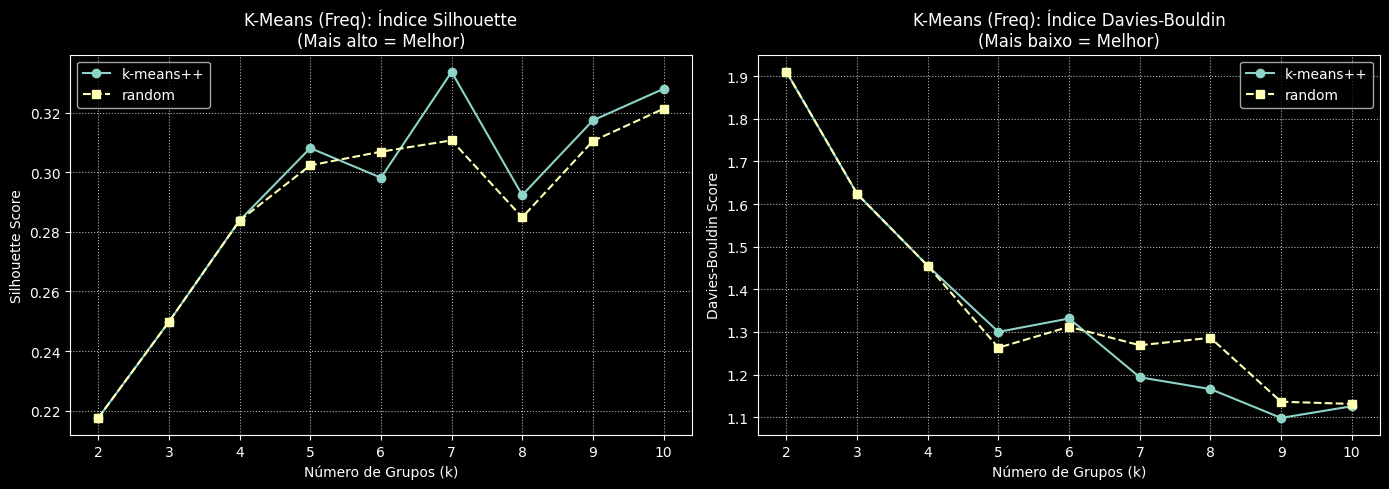

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- FASE 3: Validação Visual (Resultados K-Means com FREQUÊNCIA) ---")

#Carregando os resultados do Frequency Encoding:
df_kmeans_freq = pd.read_csv('resultados_kmeans_sus_freq.csv')

#Configurando a tela:
plt.figure(figsize=(14, 5))

#Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1)
plt.plot(df_kmeans_freq['k'], df_kmeans_freq['silhouette_kpp'], marker='o', label='k-means++')
plt.plot(df_kmeans_freq['k'], df_kmeans_freq['silhouette_random'], marker='s', linestyle='--', label='random')
plt.title('K-Means (Freq): Índice Silhouette\n(Mais alto = Melhor)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Silhouette Score')
plt.xticks(df_kmeans_freq['k'])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()


#Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2)
plt.plot(df_kmeans_freq['k'], df_kmeans_freq['db_kpp'], marker='o', label='k-means++')
plt.plot(df_kmeans_freq['k'], df_kmeans_freq['db_random'], marker='s', linestyle='--', label='random')
plt.title('K-Means (Freq): Índice Davies-Bouldin\n(Mais baixo = Melhor)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(df_kmeans_freq['k'])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()

# 3. Salvando a imagem em alta resolução para o artigo!
plt.savefig('grafico_fase3_kmeans_freq.png', dpi=300, bbox_inches='tight')
print("Imagem salva como 'grafico_fase3_kmeans_freq.png'")

plt.show()

--- FASE 3: Validação Visual (Resultados Hierárquico com FREQUÊNCIA) ---
Imagem salva como 'grafico_fase3_hierarquico_freq.png'


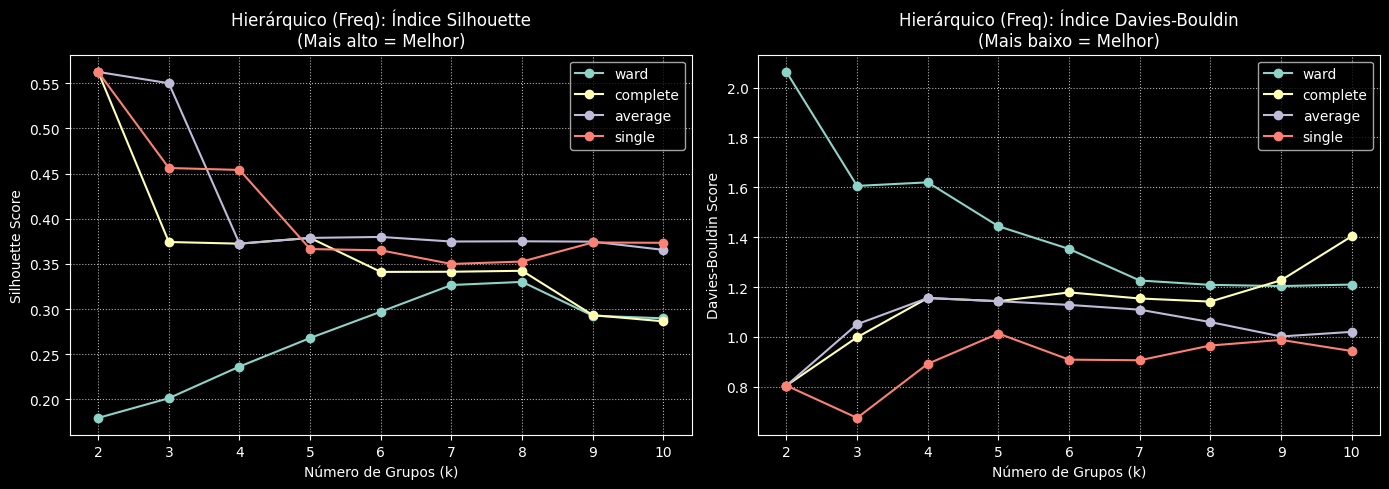

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- FASE 3: Validação Visual (Resultados Hierárquico com FREQUÊNCIA) ---")

#Carregando os resultados hierarquicos do Frequency Encoding:
df_hc_freq = pd.read_csv('resultados_hierarquico_sus_freq.csv')
linkages = df_hc_freq['linkage'].unique()

#Configurando a tela:
plt.figure(figsize=(14, 5))

#Gráfico 1: Índice Silhouette (Valor mais ALTO)
plt.subplot(1, 2, 1)
for link in linkages:
    df_plot = df_hc_freq[df_hc_freq['linkage'] == link]
    plt.plot(df_plot['k'], df_plot['silhouette'], marker='o', label=link)

plt.title('Hierárquico (Freq): Índice Silhouette\n(Mais alto = Melhor)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

#Gráfico 2: Davies-Bouldin (Valor mais BAIXO)
plt.subplot(1, 2, 2)
for link in linkages:
    df_plot = df_hc_freq[df_hc_freq['linkage'] == link]
    plt.plot(df_plot['k'], df_plot['db'], marker='o', label=link)

plt.title('Hierárquico (Freq): Índice Davies-Bouldin\n(Mais baixo = Melhor)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()

plt.savefig('grafico_fase3_hierarquico_freq.png', dpi=300, bbox_inches='tight')
print("Imagem salva como 'grafico_fase3_hierarquico_freq.png'")

plt.show()

--- FASE 3: Validação Visual (Resultados EM / Gaussian Mixture com FREQUÊNCIA) ---
Imagem salva como 'grafico_fase3_em_freq.png'


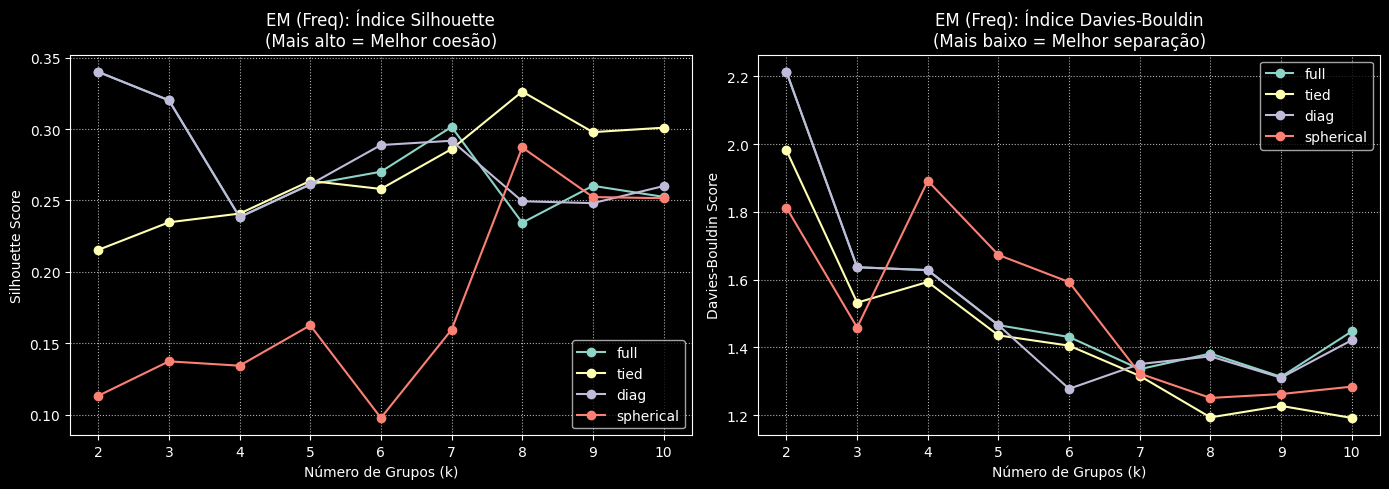

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- FASE 3: Validação Visual (Resultados EM / Gaussian Mixture com FREQUÊNCIA) ---")

#Carregando os resultados do EM (Frequency Encoding):
df_em_freq = pd.read_csv('resultados_em_sus_freq.csv')
covariances = df_em_freq['covariance_type'].unique()

#Configurando a tela de desenho:
plt.figure(figsize=(14, 5))

#Gráfico 1: Índice Silhouette (Valor mais ALTO):
plt.subplot(1, 2, 1)
for cov in covariances:
    df_plot = df_em_freq[df_em_freq['covariance_type'] == cov]
    plt.plot(df_plot['k'], df_plot['silhouette'], marker='o', label=cov)

plt.title('EM (Freq): Índice Silhouette\n(Mais alto = Melhor coesão)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

#Gráfico 2: Davies-Bouldin (Valor mais BAIXO):
plt.subplot(1, 2, 2)
for cov in covariances:
    df_plot = df_em_freq[df_em_freq['covariance_type'] == cov]
    plt.plot(df_plot['k'], df_plot['db'], marker='o', label=cov)

plt.title('EM (Freq): Índice Davies-Bouldin\n(Mais baixo = Melhor separação)')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(range(2, 11))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.tight_layout()

plt.savefig('grafico_fase3_em_freq.png', dpi=300, bbox_inches='tight')
print("Imagem salva como 'grafico_fase3_em_freq.png'")

plt.show()